# Telemetry Preprocessing Pipeline

This notebook prepares telemetry sequences for modeling.

Steps:
1. load subsystem telemetry
2. remove constant sensors
3. chronological train/validation/test split
4. normalize using training statistics
5. convert time series into sliding windows

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("default")

##  Load Subsystem

In [2]:
DATA_PATH = "/home/yuvan/Downloads/archive/data/data/train"
FILE = "D-15.npy"

x = np.load(os.path.join(DATA_PATH, FILE))
df = pd.DataFrame(x)

print("Loaded file:", FILE)
print("Shape:", df.shape)
df.head()

Loaded file: D-15.npy
Shape: (2074, 55)


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.952800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.951874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#  Sanity Checks
# Check for missing values and constant sensors.

In [4]:
print("Total NaNs:", df.isna().sum().sum())
print("Std per column:\n", df.std().head())

Total NaNs: 0
Std per column:
 0    0.655554
1    0.000000
2    0.000000
3    0.000000
4    0.000000
dtype: float64


In [5]:
##  Remove Constant Sensors

In [6]:
constant_cols = df.columns[df.std() == 0]

if len(constant_cols) > 0:
    df = df.drop(columns=constant_cols)
    print("Dropped constant columns:", list(constant_cols))
else:
    print("No constant columns found.")

print("New shape:", df.shape)

Dropped constant columns: [1, 2, 3, 4, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 34, 36, 37, 38, 40, 42, 44, 45, 46, 48, 50, 51, 52]
New shape: (2074, 15)


### Sensor Cleaning

Sensors with zero variance were removed.

These channels remain constant across the entire sequence,
so they do not contain useful temporal information.

Remaining sensors: 15

##  Time-Aware Train / Validation / Test Split

In [7]:
n = len(df)

train_end = int(0.6 * n)
val_end   = int(0.8 * n)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

Train: (1244, 15)
Val: (415, 15)
Test: (415, 15)


### Chronological Split

The telemetry sequence is split in time order:

Train: first 60%  
Validation: next 20%  
Test: final 20%

No shuffling is used because temporal order must be preserved.

In [8]:
# 🔹 Remove sensors that are constant within train split
train_std = df_train.std()

constant_train_cols = train_std[train_std == 0].index

if len(constant_train_cols) > 0:
    print("Dropping sensors constant in training split:", list(constant_train_cols))
    
    df_train = df_train.drop(columns=constant_train_cols)
    df_val   = df_val.drop(columns=constant_train_cols)
    df_test  = df_test.drop(columns=constant_train_cols)
else:
    print("No train-constant sensors found.")

print("Shapes after train-constant removal:")
print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

Dropping sensors constant in training split: [31, 53, 54]
Shapes after train-constant removal:
Train: (1244, 12)
Val: (415, 12)
Test: (415, 12)


##  Verify Split Chronology

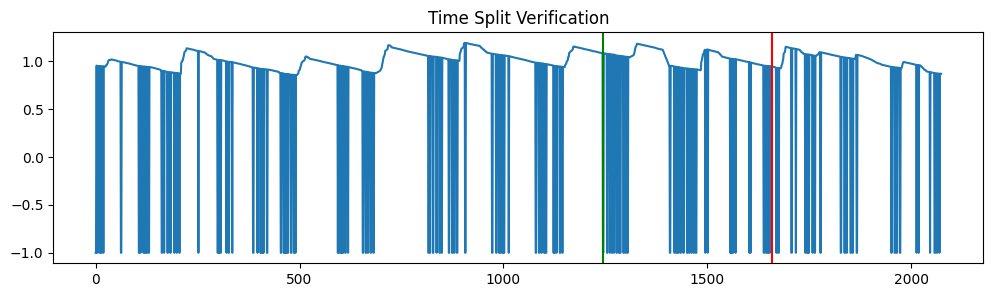

In [9]:
plt.figure(figsize=(12,3))
plt.plot(df.iloc[:,0])
plt.axvline(train_end, color="green")
plt.axvline(val_end, color="red")
plt.title("Time Split Verification")
plt.show()

##  Train-Only Normalization

In [10]:
mean = df_train.mean()
std  = df_train.std()

std[std < 1e-8] = 1e-8

df_train_norm = (df_train - mean) / std
df_val_norm   = (df_val   - mean) / std
df_test_norm  = (df_test  - mean) / std

In [11]:
np.save("data/X_train_raw.npy", df_train_norm.values)
np.save("data/X_val_raw.npy", df_val_norm.values)
np.save("data/X_test_raw.npy", df_test_norm.values)

print("Saved continuous normalized sequences.")
print("Raw train shape:", df_train_norm.values.shape)

Saved continuous normalized sequences.
Raw train shape: (1244, 12)


In [12]:
print("NaNs train:", df_train_norm.isna().sum().sum())
print("NaNs test:", df_test_norm.isna().sum().sum())

NaNs train: 0
NaNs test: 0


### Normalization

Sensors are standardized using mean and standard deviation
computed from the training set.

Validation and test data use the same statistics.

In [13]:
print("NaNs in df_train_norm:", df_train_norm.isna().sum().sum())
print("NaNs in df_val_norm:", df_val_norm.isna().sum().sum())
print("NaNs in df_test_norm:", df_test_norm.isna().sum().sum())

NaNs in df_train_norm: 0
NaNs in df_val_norm: 0
NaNs in df_test_norm: 0


##  Sliding Window Function

In [14]:
def create_windows(data, window_size, stride):
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        segment = data.iloc[i:i+window_size].values
        
        if np.isnan(segment).any():
            print("NaN found in segment starting at:", i)
        
        windows.append(segment)
    return np.stack(windows)

##  Create Sliding Windows

In [15]:
window_size = 80
stride = 5

X_train = create_windows(df_train_norm, window_size, stride)
X_val   = create_windows(df_val_norm, window_size, stride)
X_test  = create_windows(df_test_norm, window_size, stride)

print("Train windows:", X_train.shape)
print("Val windows:", X_val.shape)
print("Test windows:", X_test.shape)

Train windows: (233, 80, 12)
Val windows: (68, 80, 12)
Test windows: (68, 80, 12)


In [16]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())

NaNs in X_train: 0
NaNs in X_test: 0


### Sliding Windows

Window size: 80  
Stride: 5

The window length is chosen to capture both
short anomaly bursts and slower subsystem dynamics.

##  Sanity Check Window Structure

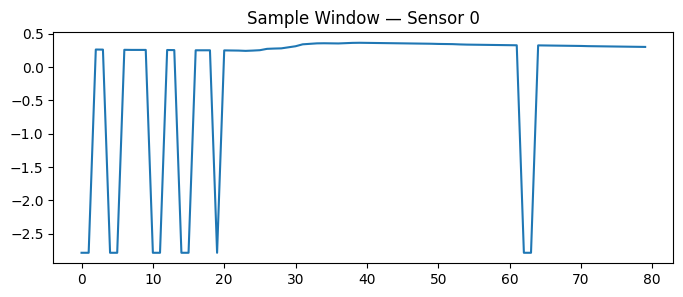

In [17]:
plt.figure(figsize=(8,3))
plt.plot(X_train[0][:,0])
plt.title("Sample Window — Sensor 0")
plt.show()

In [18]:
import os

os.makedirs("data", exist_ok=True)

np.save("data/X_train.npy", X_train)
np.save("data/X_val.npy", X_val)
np.save("data/X_test.npy", X_test)

print("Saved windowed datasets to /data folder")

Saved windowed datasets to /data folder


In [19]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())

NaNs in X_train: 0
NaNs in X_test: 0


## Result

The preprocessing pipeline produces windowed telemetry sequences
ready for temporal modeling.

Final dataset shapes:

X_train : (n_windows, 80, n_sensors)  
X_val   : (n_windows, 80, n_sensors)  
X_test  : (n_windows, 80, n_sensors)

These sequences will be used for LSTM training in the next stage.